<a href="https://colab.research.google.com/github/Galatonic-rebel/PneumoniaClassification/blob/main/PneumoniaClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pneumonia Detection from Chest X-rays using Deep Learning

# Importing Libraries



In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
import os
base_path = path + "/chest_xray"
print(os.listdir(base_path))

['chest_xray', '__MACOSX', 'val', 'test', 'train']


# Transform

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [5]:
train_dataset = datasets.ImageFolder(base_path + "/train", transform=train_transform)
val_dataset   = datasets.ImageFolder(base_path + "/val",   transform=eval_transform)
test_dataset  = datasets.ImageFolder(base_path + "/test",  transform=eval_transform)

print("Classes:", train_dataset.classes)
print(f"Train:  {len(train_dataset)} images")
print(f"Val:    {len(val_dataset)} images")
print(f"Test:   {len(test_dataset)} images")

Classes: ['NORMAL', 'PNEUMONIA']
Train:  5216 images
Val:    16 images
Test:   624 images


In [6]:
from collections import Counter

# Count samples per class
label_counts = Counter(train_dataset.targets)
total = len(train_dataset)

print(f"NORMAL:    {label_counts[0]} images")
print(f"PNEUMONIA: {label_counts[1]} images")

NORMAL:    1341 images
PNEUMONIA: 3875 images


In [7]:
# Compute weights inversely proportional to class frequency
weight_normal    = total / (2 * label_counts[0])
weight_pneumonia = total / (2 * label_counts[1])

weights = torch.tensor([weight_normal, weight_pneumonia])
print(f"\nClass weights: {weights}")


Class weights: tensor([1.9448, 0.6730])


In [8]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

In [9]:
images, labels = next(iter(train_loader))

print(f"Batch shape:  {images.shape}")   # should be [32, 3, 128, 128]
print(f"Labels:       {labels}")
print(f"Pixel range:  [{images.min():.2f}, {images.max():.2f}]")  # should be [-1, 1]

Batch shape:  torch.Size([32, 3, 128, 128])
Labels:       tensor([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
        1, 0, 0, 1, 1, 0, 1, 0])
Pixel range:  [-1.00, 1.00]


# Class Distribution

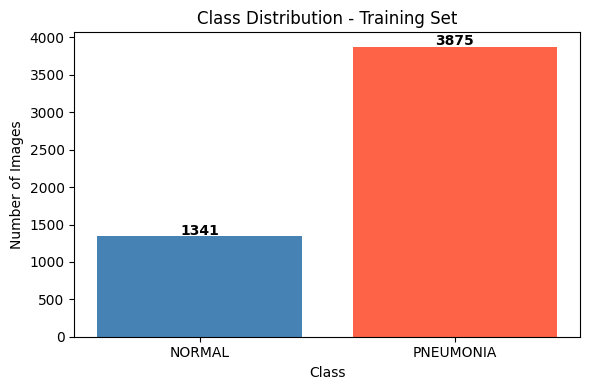

NORMAL:    1341
PNEUMONIA: 3875
Ratio:     2.89x more pneumonia than normal


In [10]:
import matplotlib.pyplot as plt
from collections import Counter

# Count classes
label_counts = Counter(train_dataset.targets)
classes = train_dataset.classes

plt.figure(figsize=(6, 4))
plt.bar(classes, [label_counts[0], label_counts[1]], color=['steelblue', 'tomato'])
plt.title("Class Distribution - Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
for i, v in enumerate([label_counts[0], label_counts[1]]):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"NORMAL:    {label_counts[0]}")
print(f"PNEUMONIA: {label_counts[1]}")
print(f"Ratio:     {label_counts[1]/label_counts[0]:.2f}x more pneumonia than normal")

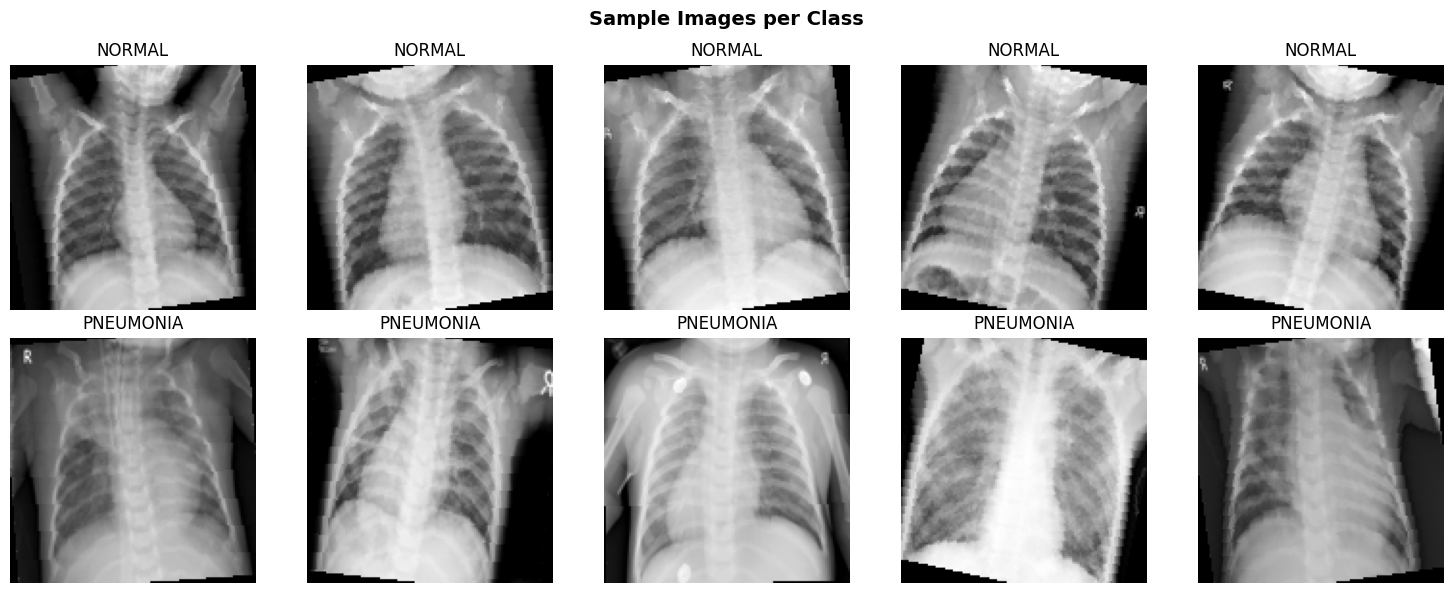

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def show_samples(dataset, classes, n=5):
    # Separate indices by class
    class_indices = {0: [], 1: []}
    for idx, label in enumerate(dataset.targets):
        class_indices[label].append(idx)

    fig, axes = plt.subplots(2, n, figsize=(15, 6))

    for class_idx in range(2):
        # Pick n random samples from each class
        samples = np.random.choice(class_indices[class_idx], n, replace=False)

        for col, sample_idx in enumerate(samples):
            image, label = dataset[sample_idx]

            # Denormalize from [-1,1] back to [0,1] for display
            image = image * 0.5 + 0.5
            image = image.permute(1, 2, 0).numpy()
            # Convert to grayscale for display since all 3 channels are identical
            image = image[:, :, 0]

            axes[class_idx, col].imshow(image, cmap='gray')
            axes[class_idx, col].axis('off')
            axes[class_idx, col].set_title(classes[class_idx])

    plt.suptitle("Sample Images per Class", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(train_dataset, train_dataset.classes, n=5)

In [14]:
def print_split_summary(train_dataset, val_dataset, test_dataset):
    classes = train_dataset.classes

    # Count per split per class
    splits = {
        'Train': Counter(train_dataset.targets),
        'Val':   Counter(val_dataset.targets),
        'Test':  Counter(test_dataset.targets),
    }

    print("=" * 45)
    print(f"{'Split':<10} {'NORMAL':>8} {'PNEUMONIA':>12} {'TOTAL':>8}")
    print("=" * 45)

    for split_name, counts in splits.items():
        normal    = counts[0]
        pneumonia = counts[1]
        total     = normal + pneumonia
        print(f"{split_name:<10} {normal:>8} {pneumonia:>12} {total:>8}")

    print("=" * 45)

    # Overall imbalance ratio
    train_counts = splits['Train']
    ratio = train_counts[1] / train_counts[0]
    print(f"\nClass imbalance ratio (train): {ratio:.2f}x")
    print(f"→ Pneumonia is {ratio:.2f}x more frequent than Normal")
    print(f"→ Class weights will be used to compensate")

print_split_summary(train_dataset, val_dataset, test_dataset)

Split        NORMAL    PNEUMONIA    TOTAL
Train          1341         3875     5216
Val               8            8       16
Test            234          390      624

Class imbalance ratio (train): 2.89x
→ Pneumonia is 2.89x more frequent than Normal
→ Class weights will be used to compensate


# Model

In [15]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [16]:
class PneumoniaClassifier(nn.Module):
    def __init__(self):
        super(PneumoniaClassifier, self).__init__()

        self.conv_layers = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 128 → 64

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 64 → 32

            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))  # → 4×4
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = PneumoniaClassifier().to(device)
print(model)

PneumoniaClassifier(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(4, 4))
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [17]:
# Create a dummy batch — same shape as your real data
dummy_input = torch.randn(32, 3, 128, 128).to(device)

# Forward pass
with torch.no_grad():
    dummy_output = model(dummy_input)

print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}")
print(f"Output sample:\n{dummy_output[0]}")

Input shape:  torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 2])
Output sample:
tensor([0.1580, 0.1113], device='cuda:0')


# Training

In [18]:
import torch.optim as optim

# Use class weights to handle imbalance
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

# Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Criterion: {criterion}")
print(f"Optimizer: {optimizer}")

Criterion: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [19]:

def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == labels).sum().item()
    return correct / labels.size(0)

In [20]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_accuracy = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_accuracy += calculate_accuracy(outputs, labels)

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = running_accuracy / len(loader)

    return epoch_loss, epoch_accuracy

In [21]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_accuracy = 0.0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            total_loss += criterion(outputs, labels).item()
            total_accuracy += calculate_accuracy(outputs, labels)

            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    avg_accuracy = total_accuracy / len(loader)

    return avg_loss, avg_accuracy, all_predictions, all_labels

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
checkpoint_path = '/content/drive/MyDrive/pneumonia_classifier/checkpoint.pth'

# Create folder if it doesn't exist
import os
os.makedirs('/content/drive/MyDrive/pneumonia_classifier', exist_ok=True)

In [24]:
num_epochs = 15
start_epoch = 0
best_val_accuracy = 0.0

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(start_epoch, num_epochs):

    # Training
    train_loss, train_accuracy = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    # Validation
    val_loss, val_accuracy, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    # Track metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Print progress
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}"
    )


Epoch [1/15] Train Loss: 0.4964 | Train Acc: 0.7586 | Val Loss: 0.6564 | Val Acc: 0.6875
Epoch [2/15] Train Loss: 0.2651 | Train Acc: 0.8924 | Val Loss: 1.6292 | Val Acc: 0.5000
Epoch [3/15] Train Loss: 0.2143 | Train Acc: 0.9202 | Val Loss: 0.7169 | Val Acc: 0.6875
Epoch [4/15] Train Loss: 0.1950 | Train Acc: 0.9314 | Val Loss: 1.2914 | Val Acc: 0.5625
Epoch [5/15] Train Loss: 0.1837 | Train Acc: 0.9340 | Val Loss: 0.8458 | Val Acc: 0.6875
Epoch [6/15] Train Loss: 0.1687 | Train Acc: 0.9406 | Val Loss: 1.0165 | Val Acc: 0.7500
Epoch [7/15] Train Loss: 0.1644 | Train Acc: 0.9408 | Val Loss: 0.6919 | Val Acc: 0.7500
Epoch [8/15] Train Loss: 0.1569 | Train Acc: 0.9440 | Val Loss: 0.8199 | Val Acc: 0.7500
Epoch [9/15] Train Loss: 0.1617 | Train Acc: 0.9394 | Val Loss: 0.6861 | Val Acc: 0.8125
Epoch [10/15] Train Loss: 0.1469 | Train Acc: 0.9454 | Val Loss: 1.0488 | Val Acc: 0.6250
Epoch [11/15] Train Loss: 0.1459 | Train Acc: 0.9488 | Val Loss: 0.7178 | Val Acc: 0.7500
Epoch [12/15] Train

In [26]:
   # Save latest checkpoint
   torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'train_accuracies': train_accuracies,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
    }, checkpoint_path)

In [28]:

    # Save best model separately
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_accuracy': val_accuracy,
        }, '/content/drive/MyDrive/pneumonia_classifier/best_model.pth')
        print(f"  ✅ Best model saved at epoch {epoch+1} | Val Acc: {val_accuracy:.4f}")

print(f"\nTraining complete.")
print(f"Best Val Accuracy: {best_val_accuracy:.4f}")


Training complete.
Best Val Accuracy: 0.6875


In [29]:
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

train_losses     = checkpoint['train_losses']
train_accuracies = checkpoint['train_accuracies']
val_losses       = checkpoint['val_losses']
val_accuracies   = checkpoint['val_accuracies']
start_epoch      = checkpoint['epoch']

print(f"Loaded checkpoint from epoch: {start_epoch + 1}")

Loaded checkpoint from epoch: 15


In [30]:
print(f"Epoch in checkpoint: {checkpoint['epoch'] + 1}")
print(f"Train losses: {train_losses}")

Epoch in checkpoint: 15
Train losses: [0.4964388536712143, 0.2650744294736283, 0.21425390172681194, 0.1950332441944286, 0.18373152068559012, 0.16873930991153044, 0.16443738732144145, 0.1568948509502996, 0.1617036110555833, 0.1468548596453813, 0.14593520663975756, 0.14178763950483564, 0.13824392983438505, 0.12655880596443006, 0.1335961592663651]


# Evaluation

In [31]:
def evaluate_test(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_accuracy = 0.0
    all_predictions = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            total_loss += criterion(outputs, labels).item()
            total_accuracy += calculate_accuracy(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, predicted = torch.max(outputs, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(loader)
    avg_accuracy = total_accuracy / len(loader)

    return avg_loss, avg_accuracy, all_predictions, all_labels, all_probs

In [32]:
print(f"Val accuracies per epoch: {val_accuracies}")
print(f"Best val accuracy: {max(val_accuracies):.4f} at epoch {val_accuracies.index(max(val_accuracies)) + 1}")

Val accuracies per epoch: [0.6875, 0.5, 0.6875, 0.5625, 0.6875, 0.75, 0.75, 0.75, 0.8125, 0.625, 0.75, 0.75, 0.6875, 0.8125, 0.6875]
Best val accuracy: 0.8125 at epoch 9


In [33]:
test_loss, test_accuracy, test_preds, test_labels, test_probs = evaluate_test(
    model, test_loader, criterion, device
)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss:     0.5634
Test Accuracy: 0.8000


# Plots

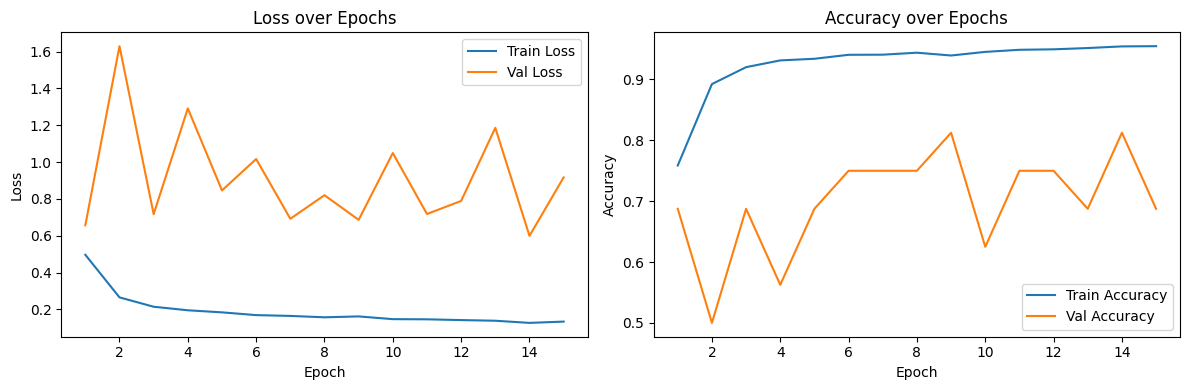

In [37]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(epochs, train_losses, label='Train Loss')
ax1.plot(epochs, val_losses, label='Val Loss')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy plot
ax2.plot(epochs, train_accuracies, label='Train Accuracy')
ax2.plot(epochs, val_accuracies, label='Val Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pneumonia_classifier/training_curves.png')  # save to Drive
plt.show()

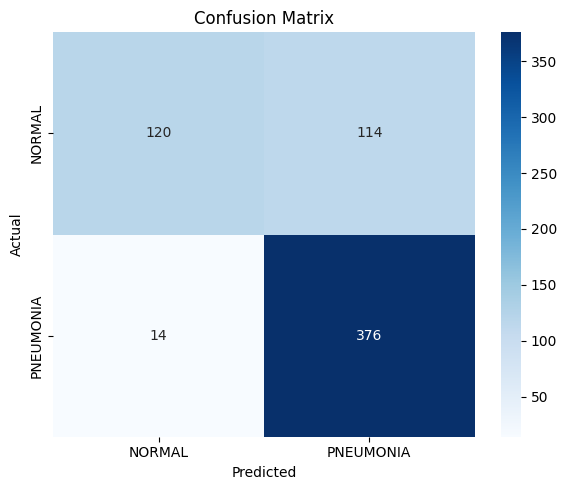


Test Loss:     0.5634
Test Accuracy: 0.8000


In [38]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Run evaluation on test set
test_loss, test_accuracy, test_preds, test_labels, test_probs = evaluate_test(
    model, test_loader, criterion, device
)

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pneumonia_classifier/confusion_matrix.png')
plt.show()

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

In [39]:
from sklearn.metrics import classification_report, roc_auc_score

print("Classification Report:")
print(classification_report(test_labels, test_preds, target_names=["NORMAL", "PNEUMONIA"]))

print(f"ROC-AUC Score: {roc_auc_score(test_labels, test_probs):.4f}")

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.90      0.51      0.65       234
   PNEUMONIA       0.77      0.96      0.85       390

    accuracy                           0.79       624
   macro avg       0.83      0.74      0.75       624
weighted avg       0.82      0.79      0.78       624

ROC-AUC Score: 0.9167


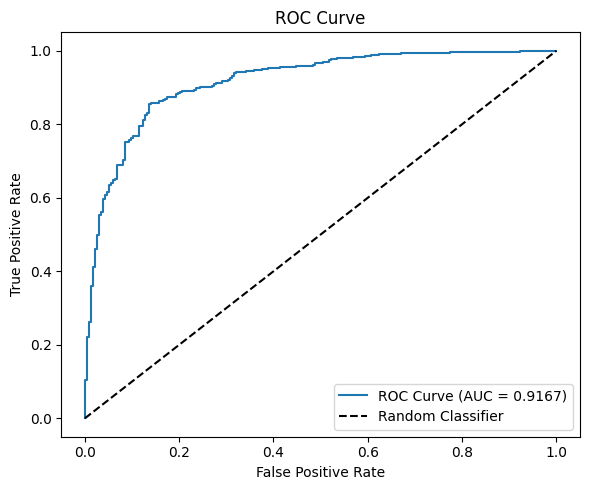

In [40]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
auc_score = roc_auc_score(test_labels, test_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pneumonia_classifier/roc_curve.png')
plt.show()

In [41]:
import cv2
import numpy as np

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        target_layer.register_forward_hook(self._save_activations)
        target_layer.register_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()

        # Forward pass
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Backward pass
        self.model.zero_grad()
        output[0, class_idx].backward()

        # Compute Grad-CAM
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()

        # Normalize
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# Attach to last conv layer
gradcam = GradCAM(model, model.conv_layers[6])  # last Conv2d in Block 3
print("GradCAM initialized")

GradCAM initialized


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


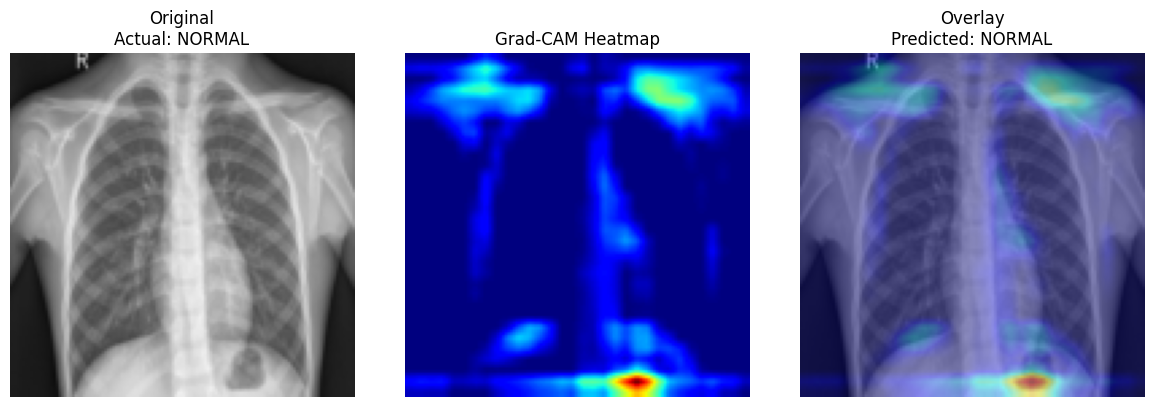

In [42]:
# Get a sample image from test set
images, labels = next(iter(test_loader))
image = images[0].unsqueeze(0).to(device)
label = labels[0].item()

# Generate Grad-CAM
cam = gradcam.generate(image)

# Convert image back to displayable format
img_display = images[0].permute(1, 2, 0).numpy()
img_display = (img_display * 0.5) + 0.5  # undo normalize
img_display = np.clip(img_display, 0, 1)

# Resize CAM to match image size
cam_resized = cv2.resize(cam, (128, 128))
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

# Overlay
overlay = 0.6 * img_display + 0.4 * heatmap
overlay = np.clip(overlay, 0, 1)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_display, cmap='gray')
axes[0].set_title(f'Original\nActual: {train_dataset.classes[label]}')
axes[0].axis('off')

axes[1].imshow(cam_resized, cmap='jet')
axes[1].set_title('Grad-CAM Heatmap')
axes[1].axis('off')

axes[2].imshow(overlay)
axes[2].set_title(f'Overlay\nPredicted: {train_dataset.classes[torch.argmax(model(image)).item()]}')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pneumonia_classifier/gradcam.png')
plt.show()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


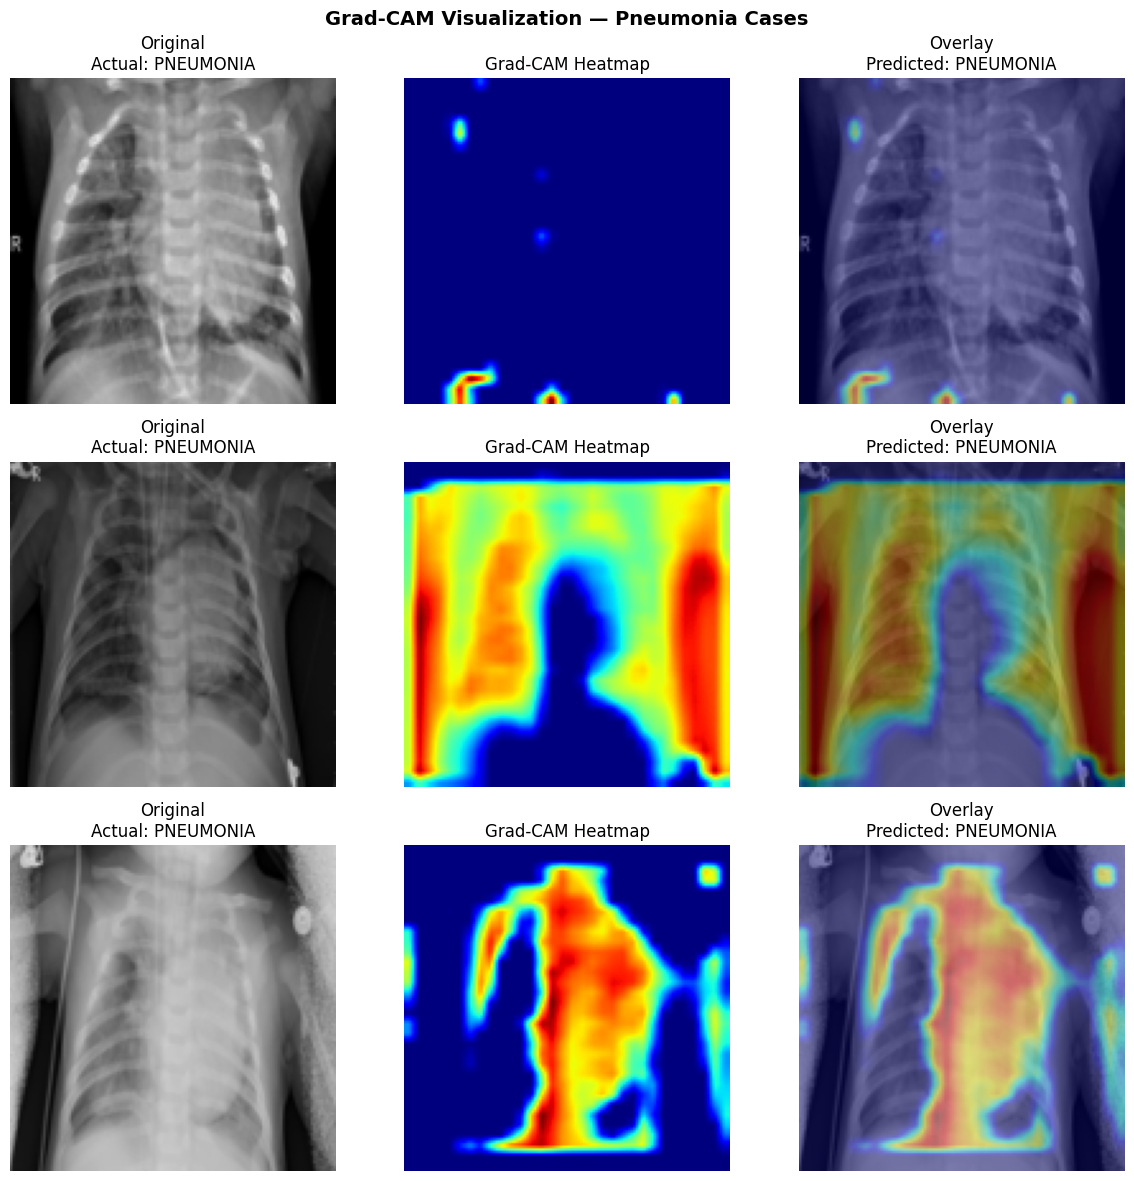

In [44]:
# Collect pneumonia images from test set
pneumonia_images = []
pneumonia_labels = []

for images, labels in test_loader:
    for i in range(len(labels)):
        if labels[i].item() == 1:  # 1 = PNEUMONIA
            pneumonia_images.append(images[i])
            pneumonia_labels.append(labels[i].item())
        if len(pneumonia_images) == 3:  # get 3 samples
            break
    if len(pneumonia_images) == 3:
        break

# Plot Grad-CAM for each pneumonia image
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for idx in range(3):
    image = pneumonia_images[idx].unsqueeze(0).to(device)
    label = pneumonia_labels[idx]

    # Generate Grad-CAM
    cam = gradcam.generate(image)

    # Convert image back to displayable format
    img_display = pneumonia_images[idx].permute(1, 2, 0).numpy()
    img_display = (img_display * 0.5) + 0.5  # undo normalize
    img_display = np.clip(img_display, 0, 1)

    # Resize CAM and create heatmap
    cam_resized = cv2.resize(cam, (128, 128))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    # Overlay
    overlay = 0.6 * img_display + 0.4 * heatmap
    overlay = np.clip(overlay, 0, 1)

    # Prediction
    pred = torch.argmax(model(image)).item()
    pred_label = train_dataset.classes[pred]

    # Plot row
    axes[idx, 0].imshow(img_display, cmap='gray')
    axes[idx, 0].set_title(f'Original\nActual: PNEUMONIA')
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(cam_resized, cmap='jet')
    axes[idx, 1].set_title('Grad-CAM Heatmap')
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(overlay)
    axes[idx, 2].set_title(f'Overlay\nPredicted: {pred_label}')
    axes[idx, 2].axis('off')

plt.suptitle('Grad-CAM Visualization — Pneumonia Cases', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/pneumonia_classifier/gradcam_pneumonia.png')
plt.show()

In [43]:
print("=" * 50)
print("        PNEUMONIA CLASSIFIER - RESULTS")
print("=" * 50)

print("\n--- Dataset ---")
print(f"Train:      {len(train_dataset)} images")
print(f"Val:        {len(val_dataset)} images")
print(f"Test:       {len(test_dataset)} images")

print("\n--- Model ---")
total_params = sum(p.numel() for p in model.parameters())
print(f"Architecture:   Simple CNN (3 conv blocks)")
print(f"Total params:   {total_params:,}")
print(f"Input size:     128x128")

print("\n--- Training ---")
print(f"Epochs:         {num_epochs}")
print(f"Optimizer:      Adam (lr=0.001)")
print(f"Loss:           CrossEntropyLoss (weighted)")
print(f"Best Val Acc:   {max(val_accuracies):.4f} at epoch {val_accuracies.index(max(val_accuracies)) + 1}")

print("\n--- Test Results ---")
print(f"Test Loss:      {test_loss:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"ROC-AUC:        {roc_auc_score(test_labels, test_probs):.4f}")

print("\n--- Classification Report ---")
print(classification_report(test_labels, test_preds, target_names=["NORMAL", "PNEUMONIA"]))
print("=" * 50)

        PNEUMONIA CLASSIFIER - RESULTS

--- Dataset ---
Train:      5216 images
Val:        16 images
Test:       624 images

--- Model ---
Architecture:   Simple CNN (3 conv blocks)
Total params:   89,314
Input size:     128x128

--- Training ---
Epochs:         15
Optimizer:      Adam (lr=0.001)
Loss:           CrossEntropyLoss (weighted)
Best Val Acc:   0.8125 at epoch 9

--- Test Results ---
Test Loss:      0.5634
Test Accuracy:  0.8000
ROC-AUC:        0.9167

--- Classification Report ---
              precision    recall  f1-score   support

      NORMAL       0.90      0.51      0.65       234
   PNEUMONIA       0.77      0.96      0.85       390

    accuracy                           0.79       624
   macro avg       0.83      0.74      0.75       624
weighted avg       0.82      0.79      0.78       624

